# SIPARTA - Sistem Pintar Deteksi Kimia Rumah Tangga
## Pipeline AI JST (Jaringan Saraf Tiruan)
Notebook ini merangkum seluruh alur (pipeline) pemrosesan AI untuk SIPARTA, menyinkronkan logika dari `train_real_sensors.py`, `inference.py`, dan simulasi dari `main_rpi.py`.

### Tahapan Pipeline:
1. Konfigurasi dan Environment
2. Akuisisi dan Pemuatan Dataset
3. Eksplorasi dan Validasi Data
4. Preprocessing
5. Pembangunan Arsitektur JST
6. Training dan Evaluasi
7. Penyimpanan Artefak
8. Simulasi dan Validasi Inference
9. Integrasi Alur Raspberry Pi
10. Ekspor dan Kesiapan Deployment

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi Environment & Seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")

I0000 00:00:1790906744.282056   99385 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790906744.674071   99385 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790906746.000380   99385 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow Version: 2.21.0


## 2. Akuisisi dan Pemuatan Dataset
Logika dataset sesuai dengan `train_real_sensors.py`. 
Sistem membaca 4 input sensor: MICS-5524, TGS2600, MQ-2, MQ-135.

In [2]:
# Simulasi data analog voltage (0.0 to 5.0 V) berdasarkan train_real_sensors.py
print("Menyiapkan dataset sensor fisik...")

# AMAN (Safe): Normal air (0.1 - 1.2 V)
aman_data = np.random.uniform(low=0.1, high=1.2, size=(1000, 4))
aman_labels = np.array([0] * 1000)

# WASPADA (Warning): Slight elevation (1.2 - 2.5 V)
waspada_data = np.random.uniform(low=1.2, high=2.5, size=(1000, 4))
waspada_labels = np.array([1] * 1000)

# BAHAYA (Danger): High concentration (2.5 - 4.8 V)
bahaya_data = np.random.uniform(low=2.5, high=4.8, size=(1000, 4))
bahaya_labels = np.array([2] * 1000)

X = np.vstack((aman_data, waspada_data, bahaya_data))
y = np.concatenate((aman_labels, waspada_labels, bahaya_labels))

df = pd.DataFrame(X, columns=['mics5524', 'tgs2600', 'mq2', 'mq135'])
df['label'] = y
df.to_csv('siparta_sensor_dataset.csv', index=False)
print(f"Dataset disimpan: siparta_sensor_dataset.csv (Shape: {df.shape})")
display(df.head())

Menyiapkan dataset sensor fisik...
Dataset disimpan: siparta_sensor_dataset.csv (Shape: (3000, 5))


,mics5524,tgs2600,mq2,mq135,label
0,0.511994,1.145786,0.905193,0.758524,0
1,0.271621,0.271594,0.163892,1.052794,0
2,0.761227,0.878880,0.122643,1.166901,0
3,1.015687,0.333573,0.300007,0.301745,0
4,0.434666,0.677232,0.575140,0.420352,0


## 3. Eksplorasi dan Validasi Data
Memastikan distribusi label seimbang.

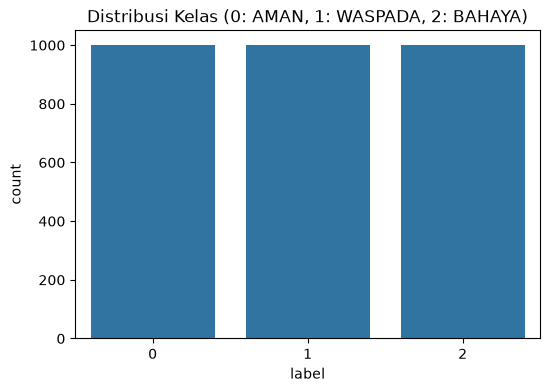

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title("Distribusi Kelas (0: AMAN, 1: WASPADA, 2: BAHAYA)")
plt.show()

## 4. Preprocessing
Split data (80/20) dan standarisasi menggunakan `StandardScaler`. Skaler disimpan agar dapat digunakan oleh inference.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi label ke One-Hot Encoding
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=3)

## 5. Pembangunan Arsitektur JST
Model Sequential dengan dense layers dan dropout untuk mencegah overfitting.

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/brayone-xv/Documents/My File/CODE/lomba/pkm-kc/SIPARTA/ai_models/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790906747.859743   99385 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1790906747.860034   99490 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1790906747.883222   99385 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned abo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Training dan Evaluasi
Melatih model JST menggunakan data sensor berskala.

In [6]:
history = model.fit(
    X_train_scaled, y_train_cat, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1
)

loss, acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {acc*100:.2f}%")

Epoch 1/20


 1/60 ━━━━━━━━━━━━━━━━━━━━ 37s 638ms/step - accuracy: 0.5938 - loss: 1.0641

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8568 - loss: 0.3492 - val_accuracy: 1.0000 - val_loss: 0.0211


Epoch 2/20


 1/60 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9688 - loss: 0.0820

...

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9990 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 3.3732e-04


Epoch 20/20


 1/60 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 1.7471e-04

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9969 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 2.4731e-05



Test Accuracy: 100.00%


## 7. Penyimpanan Artefak
Menyimpan `scaler` (pkl), model h5/keras, dan model TFLite untuk deployment Edge.

In [7]:
model_dir = "model"
os.makedirs(model_dir, exist_ok=True)

# 1. Simpan Scaler
scaler_path = os.path.join(model_dir, 'siparta_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

# 2. Simpan Keras Model (untuk backend)
keras_path = os.path.join(model_dir, 'siparta_ann.keras')
model.save(keras_path)
h5_path = os.path.join(model_dir, 'siparta_ann.h5')
model.save(h5_path) # Kompatibilitas Keras legacy

# 3. Simpan TFLite (untuk RPi)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path = os.path.join(model_dir, 'siparta_ann.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print("Artefak model dan scaler berhasil disimpan di direktori 'model/'.")

INFO:tensorflow:Assets written to: /tmp/tmph2rirst3/assets


INFO:tensorflow:Assets written to: /tmp/tmph2rirst3/assets


Saved artifact at '/tmp/tmph2rirst3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135394117362960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135388761027216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135388761027792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135388761025104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135388761026832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135388761028368: TensorSpec(shape=(), dtype=tf.resource, name=None)


Artefak model dan scaler berhasil disimpan di direktori 'model/'.


W0000 00:00:1790906750.828532   99385 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790906750.828543   99385 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790906750.828710   99385 reader.cc:83] Reading SavedModel from: /tmp/tmph2rirst3
I0000 00:00:1790906750.829055   99385 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790906750.829064   99385 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmph2rirst3
I0000 00:00:1790906750.831841   99385 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790906750.832285   99385 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790906750.846960   99385 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmph2rirst3
I0000 00:00:1790906750.851497   99385 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 22791 microseconds.
I0000 00:00:1790906750.867744   99385

## 8. Simulasi dan Validasi Inference
Mengadopsi logika dari `inference.py` untuk memastikan model yang diekspor dapat digunakan.

In [8]:
class InferenceEngineSim:
    def __init__(self, tflite_path, scaler_path):
        self.interpreter = tf.lite.Interpreter(model_path=tflite_path)
        self.interpreter.allocate_tensors()
        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()
        
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)

    def preprocess(self, sensor_values):
        clamped = [max(0.0, min(5.0, v)) for v in sensor_values]
        input_data = np.array([clamped], dtype=np.float32)
        return self.scaler.transform(input_data).astype(np.float32)

    def predict(self, sensor_values):
        input_data = self.preprocess(sensor_values)
        self.interpreter.set_tensor(self.input_details[0]['index'], input_data)
        self.interpreter.invoke()
        output = self.interpreter.get_tensor(self.output_details[0]['index'])[0]
        
        classes = ["AMAN", "WASPADA", "BAHAYA"]
        idx = np.argmax(output)
        return classes[idx]

engine = InferenceEngineSim(tflite_path, scaler_path)

# Test Inference
test_sensor_aman = [0.5, 0.6, 0.4, 0.3]
test_sensor_bahaya = [4.5, 3.8, 4.2, 4.0]

print("Test AMAN  :", engine.predict(test_sensor_aman))
print("Test BAHAYA:", engine.predict(test_sensor_bahaya))

Test AMAN  : AMAN
Test BAHAYA: BAHAYA


/home/brayone-xv/Documents/My File/CODE/lomba/pkm-kc/SIPARTA/ai_models/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 9. Integrasi Alur Raspberry Pi
Mengadopsi logika payload operasional dari `main_rpi.py`, tanpa akses perangkat keras (GPIO/I2C).

In [9]:
from datetime import datetime, timezone
import json

def simulate_send_report(sensor_data, status, device_id="TEST_DEVICE_01"):
    """Simulasi fungsi send_report_to_backend dari main_rpi.py"""
    payload = {
        "status": status,
        "sensor_mics5524": str(sensor_data[0]),
        "sensor_tgs2600": str(sensor_data[1]),
        "sensor_mq2": str(sensor_data[2]),
        "sensor_mq135": str(sensor_data[3]),
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "device_id": device_id,
    }
    
    print("[SIMULASI] Laporan Insiden Dikirim:")
    print(json.dumps(payload, indent=2))
    return True

# Simulasi loop sensor
dummy_readings = [
    ([0.4, 0.5, 0.2, 0.3], "Aman"),
    ([3.5, 4.0, 3.2, 4.5], "Ada Kebocoran Gas!")
]

for reading, note in dummy_readings:
    print(f"\n--- Mengukur Sensor ({note}) ---")
    status = engine.predict(reading)
    print(f"Hasil Klasifikasi AI: {status}")
    if status in ["WASPADA", "BAHAYA"]:
        simulate_send_report(reading, status)


--- Mengukur Sensor (Aman) ---
Hasil Klasifikasi AI: AMAN

--- Mengukur Sensor (Ada Kebocoran Gas!) ---
Hasil Klasifikasi AI: BAHAYA
[SIMULASI] Laporan Insiden Dikirim:
{
  "status": "BAHAYA",
  "sensor_mics5524": "3.5",
  "sensor_tgs2600": "4.0",
  "sensor_mq2": "3.2",
  "sensor_mq135": "4.5",
  "timestamp": "2026-10-02T02:05:50.958712+00:00",
  "device_id": "TEST_DEVICE_01"
}


## 10. Ekspor dan Kesiapan Deployment
Verifikasi akhir kesiapan artefak untuk FastAPI Backend dan Raspberry Pi.

In [10]:
print("✅ Model siap untuk didistribusikan.")
print(f"- Backend model path: {keras_path} / {h5_path}")
print(f"- Edge model path: {tflite_path}")
print(f"- Scaler path: {scaler_path}")
print("\nNotebook selesai dieksekusi dengan aman tanpa kebocoran data.")

✅ Model siap untuk didistribusikan.
- Backend model path: model/siparta_ann.keras / model/siparta_ann.h5
- Edge model path: model/siparta_ann.tflite
- Scaler path: model/siparta_scaler.pkl

Notebook selesai dieksekusi dengan aman tanpa kebocoran data.
